# 1

In [321]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt 

def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Критические значения:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')
    
    if result[1] < 0.05:
        print("Ряд стационарен (отвергаем H0)")
    else:
        print("Ряд нестационарен (не отвергаем H0)")

In [322]:
path = !pwd

In [323]:
dfs = pd.read_csv(f'{path[0]}/daily-total-female-births-in-cal.csv', parse_dates=['Date'], index_col='Date')

In [324]:
dfs.head()

,Count
Date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44


In [325]:
dfnots= pd.read_csv(f'{path[0]}/international-airline-passengers.csv', index_col='Month')

In [326]:
dfnots.head()

,Count
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


In [327]:
adf_test(dfns)

ADF Statistic: 0.8153688792060421
p-value: 0.9918802434376409
Критические значения:
   1%: -3.4816817173418295
   5%: -2.8840418343195267
   10%: -2.578770059171598
Ряд нестационарен (не отвергаем H0)


In [328]:
adf_test(dfnots)

ADF Statistic: 0.8153688792060421
p-value: 0.9918802434376409
Критические значения:
   1%: -3.4816817173418295
   5%: -2.8840418343195267
   10%: -2.578770059171598
Ряд нестационарен (не отвергаем H0)


# 2

## MA dfs

In [329]:
def moving_average(series, n):
    if not isinstance(series, pd.Series):
        series = pd.Series(series)
    return series.rolling(n).mean()


In [330]:
ser = moving_average(dfs["Count"], 7)

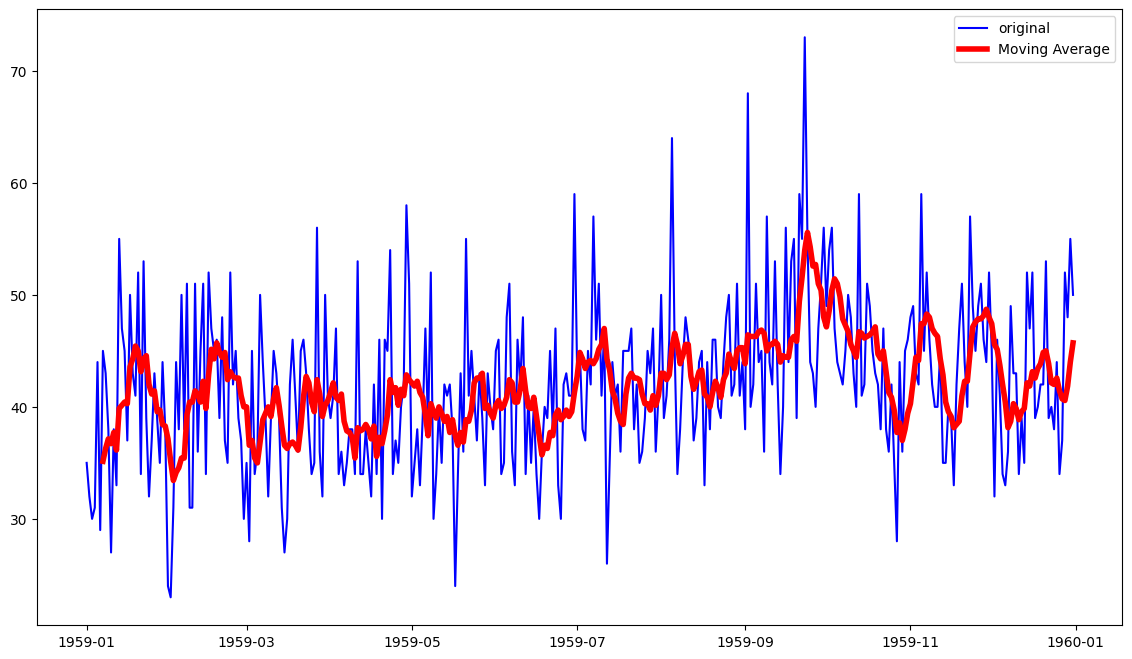

In [331]:

plt.figure(figsize=(14, 8))
plt.plot(dfs["Count"], color='blue',label='original')
plt.plot(ser, color='red', linewidth='4', label='Moving Average')
plt.legend()
plt.show()

In [332]:
train = dfs.iloc[:200]
test = dfs.iloc[200:]

In [333]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def mae(col):
    periods = range(2, 50)
    mae_scores = []

    for p in periods:
        pred_train = moving_average(col, p)
        mae = mean_absolute_error(col.iloc[p:], pred_train.iloc[p:]) 
        mae_scores.append(mae)
        
    best_period = periods[np.argmin(mae_scores)]
    print(f"Лучший период: {best_period}, MAE: {min(mae_scores):.2f}")
    return best_period

In [334]:
mae(train['Count'])

Лучший период: 2, MAE: 3.87


2

In [335]:
test_pred = moving_average(test['Count'], best_period)  # Используем всю историю для "прогноза"

test_pred = test_pred[test.index]


rmse_test = np.sqrt(mean_squared_error(test.iloc[1:], test_pred.dropna()))

print(f"RMSE на тесте: {rmse_test:.2f}")

RMSE на тесте: 4.37


## MA *dfnots*

In [336]:
ser = moving_average(dfnots["Count"], 7)

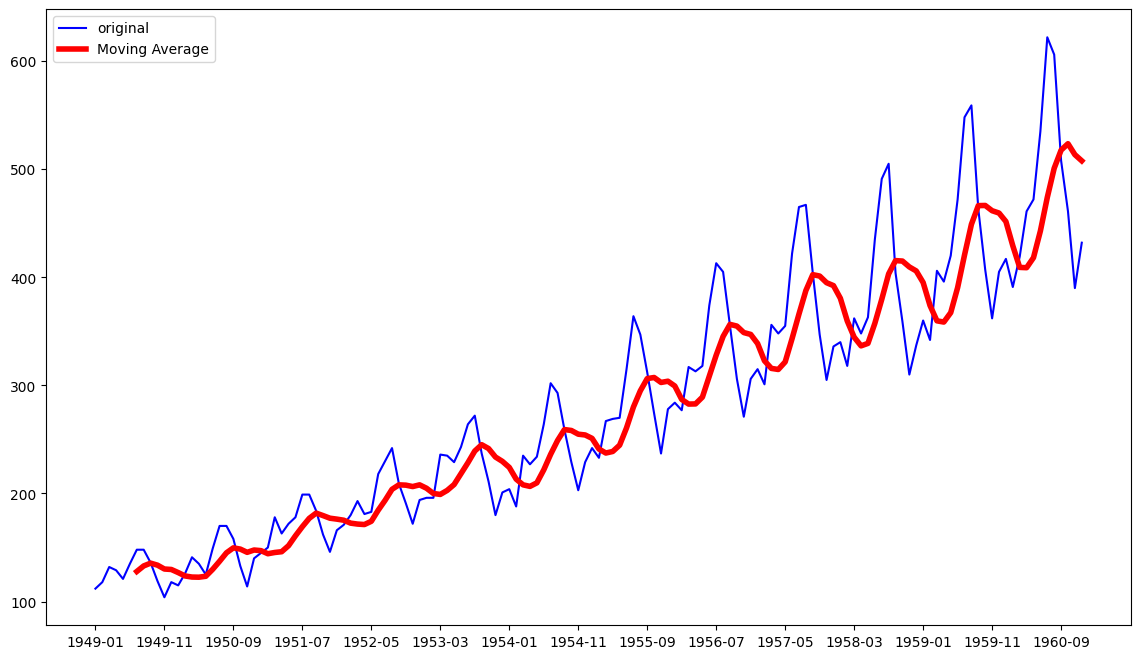

In [337]:

plt.figure(figsize=(14, 8))
plt.plot(dfnots["Count"], color='blue',label='original')
plt.plot(ser, color='red', linewidth='4', label='Moving Average')
plt.xticks(dfnots.index[::10])
plt.legend()
plt.show()

In [338]:
train = dfnots.iloc[:100]
test = dfnots.iloc[100:]

In [339]:
mae(train['Count'])

Лучший период: 2, MAE: 9.47


2

In [340]:
test_pred = moving_average(test['Count'], best_period)  

test_pred = test_pred[test.index]


rmse_test = np.sqrt(mean_squared_error(test.iloc[1:], test_pred.dropna()))

print(f"RMSE на тесте: {rmse_test:.2f}")

RMSE на тесте: 24.98


## EMA dfs

In [341]:
def calculate_ema(data, period=20):
    return pd.Series(data).ewm(span=period, adjust=False).mean()

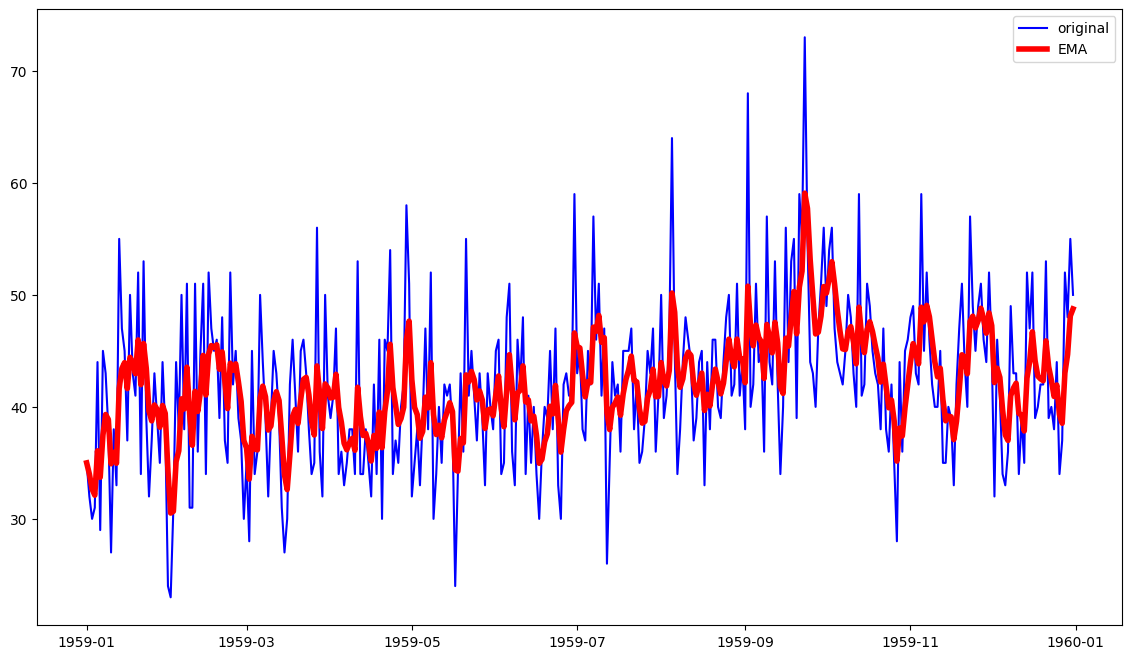

In [342]:
ema = calculate_ema(dfs["Count"], 5)

plt.figure(figsize=(14, 8))
plt.plot(dfs["Count"], color='blue',label='original')
plt.plot(ema, color='red', linewidth='4', label='EMA')
plt.legend()
plt.show()

In [343]:
train = dfs.iloc[:200]
test = dfs.iloc[200:]

In [344]:

from sklearn.metrics import mean_absolute_error, mean_squared_error
def ema_mae(col):
    periods = range(2, 50)
    mae_scores = []

    for p in periods:
        pred_train = calculate_ema(col, p)
        mae = mean_absolute_error(col.iloc[p:], pred_train.iloc[p:]) 
        mae_scores.append(mae)
        
    best_period = periods[np.argmin(mae_scores)]
    print(f"Лучший период: {best_period}, MAE: {min(mae_scores):.2f}")
    return best_period


In [345]:
ema_mae(train['Count'])

Лучший период: 2, MAE: 2.24


2

In [346]:
test_pred = calculate_ema(test['Count'], best_period) 

test_pred = test_pred[test.index]

In [347]:


rmse_test = np.sqrt(mean_squared_error(test, test_pred))

print(f"RMSE на тесте: {rmse_test:.2f}")

RMSE на тесте: 2.57


## EMA *dfnots*

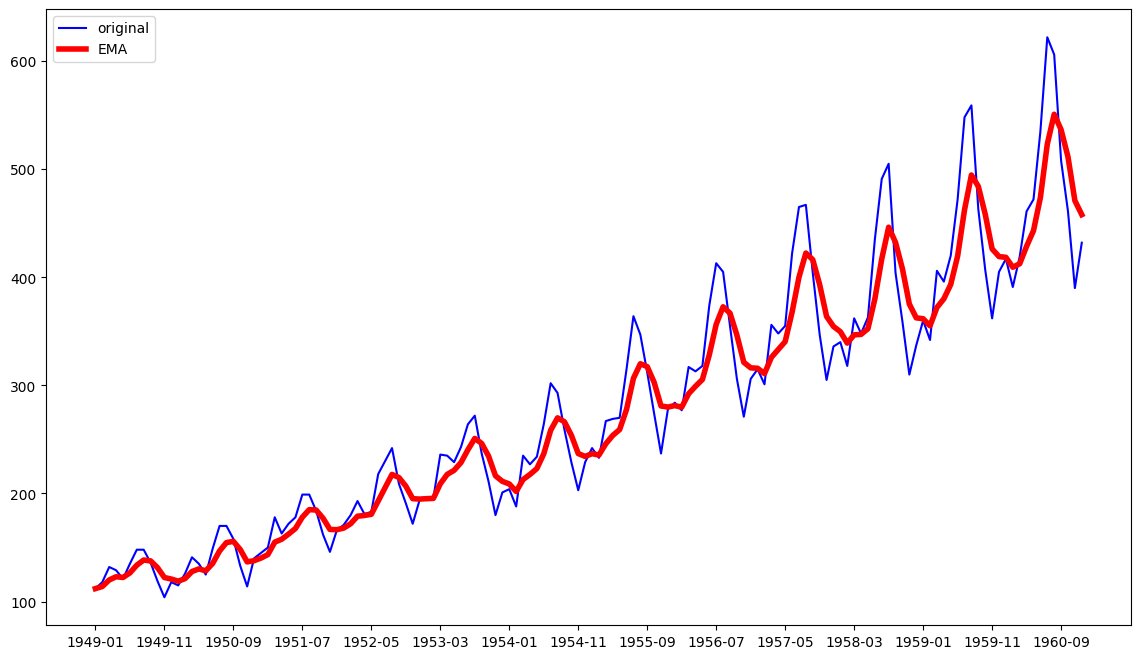

In [348]:
ema = calculate_ema(dfnots["Count"], 5)

plt.figure(figsize=(14, 8))
plt.plot(dfnots["Count"], color='blue',label='original')
plt.plot(ema, color='red', linewidth='4', label='EMA')
plt.legend()
plt.xticks((list(dfnots.index[:-1:10])))
plt.show()

In [349]:
train = dfnots.iloc[:100]
test = dfnots.iloc[100:]

In [350]:
ema_mae(train['Count'])

Лучший период: 2, MAE: 6.91


2

In [351]:
test_pred = calculate_ema(test['Count'], best_period)

test_pred = test_pred[test.index]

In [352]:


rmse_test = np.sqrt(mean_squared_error(test, test_pred))

print(f"RMSE на тесте: {rmse_test:.2f}")

RMSE на тесте: 18.99


# DEMA

## DEMA dfs

In [353]:

def calculate_dema(count, period):

    s = pd.Series(count)
    ema1 = s.ewm(span=period, adjust=False).mean()  
    ema2 = ema1.ewm(span=period, adjust=False).mean() 
    dema = 2 * ema1 - ema2
    
    return dema


In [354]:
dema = calculate_dema(dfs["Count"], 20)

In [355]:
dfs['dema'] = dema

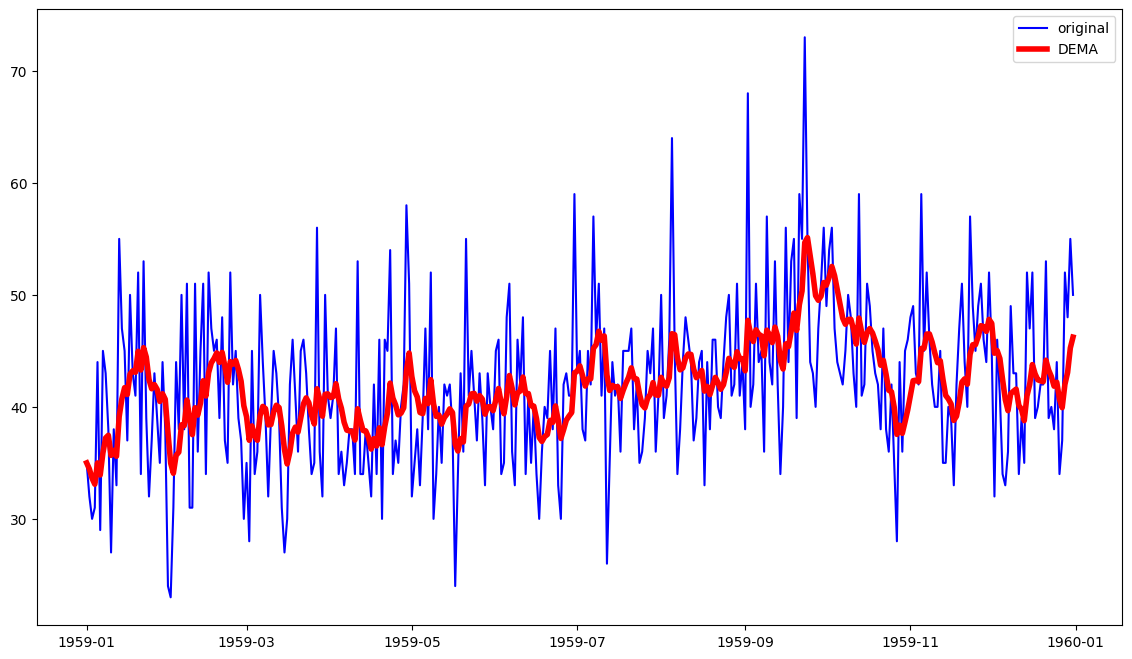

In [356]:
plt.figure(figsize=(14, 8))
plt.plot(dfs["Count"], color='blue',label='original')
plt.plot(dfs[['dema']], color='red', linewidth='4', label='DEMA')
plt.legend()
#plt.xticks((list(dfnots.index[:-1:10])))
plt.show()

In [357]:
dfs.drop('dema',axis=1, inplace=True)

In [358]:
train = dfs.iloc[:200]
test = dfs.iloc[200:]

In [359]:

from sklearn.metrics import mean_absolute_error, mean_squared_error
def dema_mae(col):
    periods = range(2, 50)
    mae_scores = []

    for p in periods:
        pred_train = calculate_dema(col, p)
        mae = mean_absolute_error(col.iloc[p:], pred_train.iloc[p:]) 
        mae_scores.append(mae)
        
    best_period = periods[np.argmin(mae_scores)]
    print(f"Лучший период: {best_period}, MAE: {min(mae_scores):.2f}")
    return best_period


In [360]:
dema_mae(train['Count'])

Лучший период: 2, MAE: 1.02


2

In [361]:
test_pred = calculate_dema(test['Count'], best_period) 

test_pred = test_pred[test.index]

In [362]:
rmse_test = np.sqrt(mean_squared_error(test.Count, test_pred))

print(f"RMSE на тесте: {rmse_test:.2f}")

RMSE на тесте: 1.15


## DEMA *dfnots*

In [363]:
dema = calculate_dema(dfns["Count"], 20)

In [364]:
dfnots['dema'] = dema

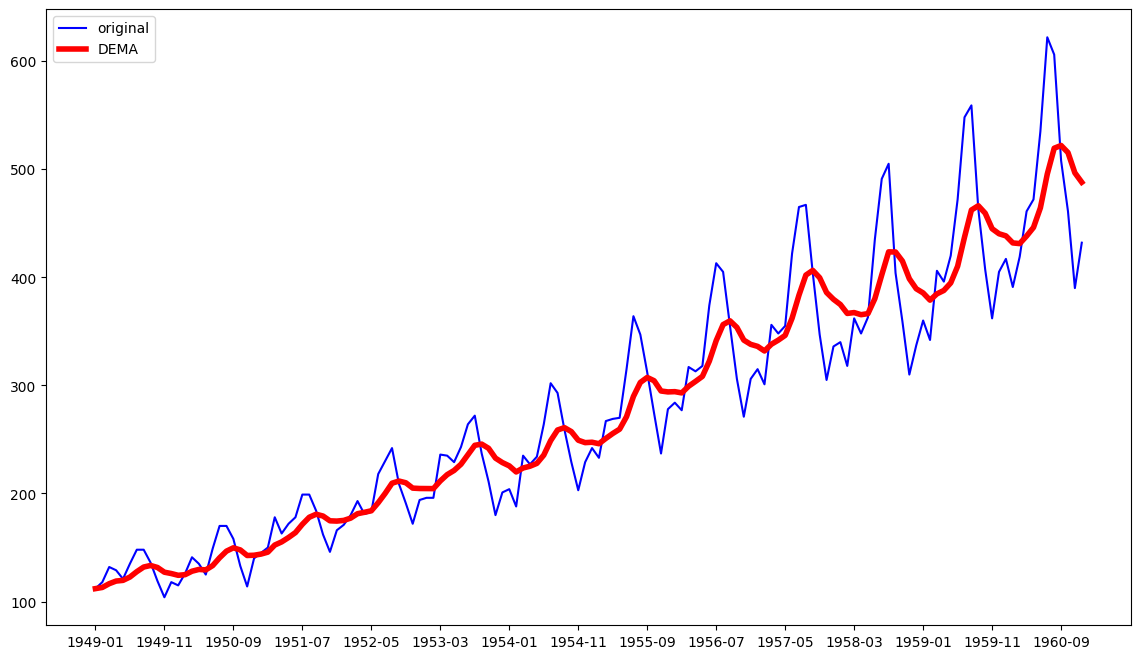

In [365]:
plt.figure(figsize=(14, 8))
plt.plot(dfnots["Count"], color='blue',label='original')
plt.plot(dfnots[['dema']], color='red', linewidth='4', label='DEMA')
plt.legend()
plt.xticks((list(dfnots.index[:-1:10])))
plt.show()

In [366]:
dfnots.drop('dema', axis=1, inplace=True)

In [387]:
train = dfnots.iloc[:100]
test = dfnots.iloc[100:]

In [388]:
dema_mae(train['Count'])

Лучший период: 2, MAE: 2.43


2

In [389]:
test_pred = calculate_dema(test['Count'], best_period)  # Используем всю историю для "прогноза"

test_pred = test_pred[test.index]

In [390]:
rmse_test = np.sqrt(mean_squared_error(test.Count, test_pred))

print(f"RMSE на тесте: {rmse_test:.2f}")

RMSE на тесте: 6.34


# TEMA

## TEMA dfs

In [371]:

def calculate_tema(series, period):

    ema1 = series.ewm(span=period, adjust=False).mean()
    ema2 = ema1.ewm(span=period, adjust=False).mean()
    ema3 = ema2.ewm(span=period, adjust=False).mean()
    tema = 3 * (ema1 - ema2) + ema3
    return tema

In [372]:
dfs['tema'] = calculate_tema(dfs['Count'], period=10)

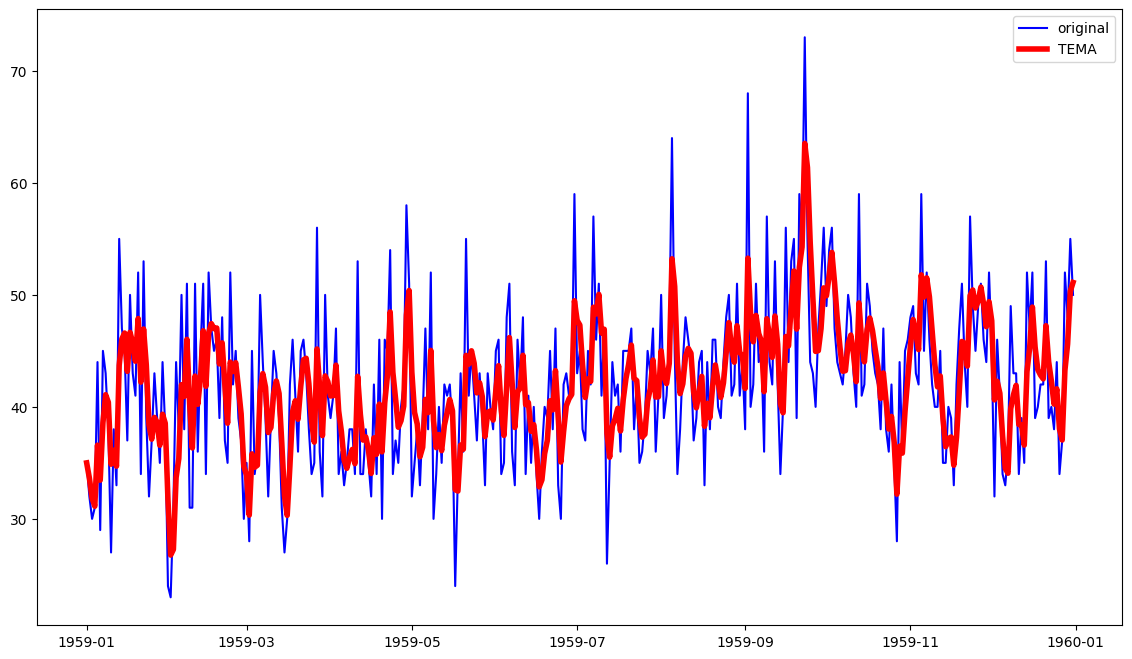

In [373]:
plt.figure(figsize=(14, 8))
plt.plot(dfs["Count"], color='blue',label='original')
plt.plot(dfs[['tema']], color='red', linewidth='4', label='TEMA')
plt.legend()
#plt.xticks((list(dfnots.index[:-1:10])))
plt.show()

In [374]:
dfs.drop('tema', axis=1, inplace=True)

In [375]:
train = dfs.iloc[:200]
test = dfs.iloc[200:]

In [376]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def tema_mae(col):
    periods = range(2, 50)
    mae_scores = []

    for p in periods:
        pred_train = calculate_tema(col, p)
        mae = mean_absolute_error(col.iloc[p:], pred_train.iloc[p:]) 
        mae_scores.append(mae)
        
    best_period = periods[np.argmin(mae_scores)]
    print(f"Лучший период: {best_period}, MAE: {min(mae_scores):.2f}")
    return best_period

In [377]:
tema_mae(train['Count'])

Лучший период: 2, MAE: 0.48


2

In [378]:
test_pred = calculate_tema(test['Count'], best_period)
test_pred = test_pred[test.index]

In [379]:

rmse_test = np.sqrt(mean_squared_error(test, test_pred))

print(f"RMSE на тесте: {rmse_test:.2f}")

RMSE на тесте: 0.54


## TEMA *dfnots

In [380]:
dfnots['tema'] = calculate_tema(dfnots['Count'], period=10)

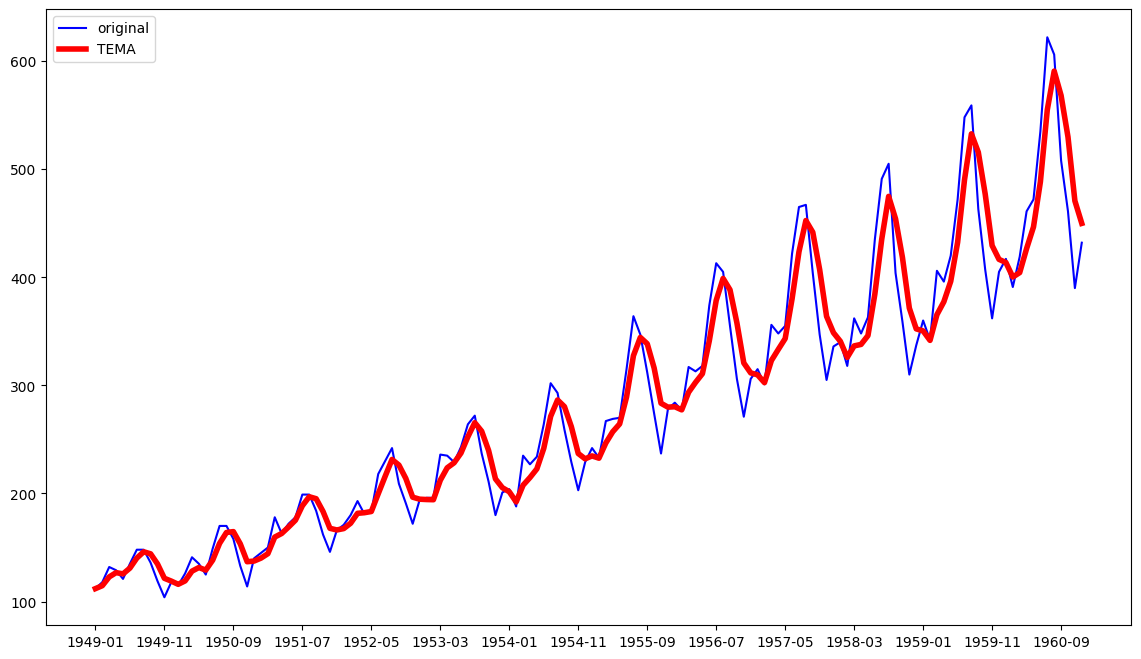

In [381]:
plt.figure(figsize=(14, 8))
plt.plot(dfnots["Count"], color='blue',label='original')
plt.plot(dfnots[['tema']], color='red', linewidth='4', label='TEMA')
plt.legend()
plt.xticks((list(dfnots.index[:-1:10])))
plt.show()

In [382]:
dfnots.drop('tema', axis=1, inplace=True)

In [383]:
train = dfnots.iloc[:100]
test = dfnots.iloc[100:]

In [384]:
tema_mae(train['Count'])

Лучший период: 2, MAE: 0.98


2

In [385]:
test_pred = calculate_tema(test['Count'], best_period)
test_pred = test_pred[test.index]

In [386]:

rmse_test = np.sqrt(mean_squared_error(test, test_pred))

print(f"RMSE на тесте: {rmse_test:.2f}")

RMSE на тесте: 2.43


Лучше всех с прогнозированием справились ТЕМА и ДЕМА для обоих рядов, для стационарных неплохо себя показала ЕМА. Очевидно ТЕМА и ДЕМА лучше справились потому что они лишь усиляют ЕМА и хорошо гасят колебания, тренды и так далее. ЕМА подойдет для стационарных потому что меньше реагирует на разного рода колебания (пики)